### Coleta da tabela de Investimentos

Importação das bibliotecas necessárias e configuração do navegador Chrome utilizando o Selenium. O script cria uma instância invisível/automatizada do navegador para buscar e extrair a tabela bruta de investimentos na página alvo.

In [ ]:
%load_ext autoreload
%autoreload 2

import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd

from constantes import (
    COLETA_INVESTIMENTOS_1995_2010
)

from funcoes import coleta_tabelas

options = webdriver.ChromeOptions()
meu_navegador = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

df_temp = coleta_tabelas(meu_navegador, COLETA_INVESTIMENTOS_1995_2010, "2010", "R33", "960")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Salva os dados recém-extraídos em um arquivo `.csv` local. Isso é uma boa prática para evitar que tenhamos que rodar o web scraping novamente caso o código seja reiniciado, poupando tempo e requisições ao servidor. Em seguida, exibimos a tabela bruta.

In [162]:
df_temp.to_csv("investimentos_1995_2010.csv", index=False)
df_temp

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
0,--> Busca Em todos os anos 2017 2016 2015 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Busca Em todos os anos 2017 2016 2015 2014 ...,NaN,Menu,NaN,Imprimir,NaN,Anterior,NaN,Próximo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Database Brasil 2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,33. Evolução dos investimentos na produção aud...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Investimentos19951996199719981999 Lei do Audio...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Investimentos,1995,1996,1997,1998,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Lei do Audiovisual (Art. 1º),16.848.507,50.449.952,75.917.001,39.093.362,37.766.848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A tabela bruta trazida do site possui muitos cabeçalhos sujos e linhas vazias, além de ser dividida em "blocos" de anos. Aqui, usamos o comando `.iloc` para visualizar e recortar a parte da tabela que contém apenas os dados do primeiro bloco, referente aos anos de 1995 a 1999.

In [163]:
df_temp.iloc[8:, 0:6]

,0,1,2,3,4,5
8,Investimentos,1995,1996,1997,1998,1999
9,Lei do Audiovisual (Art. 1º),16.848.507,50.449.952,75.917.001,39.093.362,37.766.848
10,Lei do Audiovisual (Art. 1ºA),-,-,-,-,-
11,Lei do Audiovisual (Art. 3º),4.030.992,7.319.787,3.848.491,3.999.707,3.865.016
12,Lei do Audiovisual (Art. 3ºA),-,-,-,-,-
13,Lei Rouanet,8.055.982,17.946.984,34.245.587,30.060.457,19.164.603
14,Conversão da dívida,-,-,-,-,952.653
15,Programa Mais Cinema,-,-,-,-,7.041.667
16,Orçamento da União,1.600.000,3.835.840,9.822.212,5.541.491,11.703.668
17,Art. 39 (Condecine 3%),-,-,-,-,-


Isolamos os dados do período de 1995 a 1999 em um DataFrame chamado `df_95_99`, pegando apenas as linhas e colunas com informações úteis.

In [164]:
df_95_99 = df_temp.iloc[8:20, 0:6]
df_95_99

,0,1,2,3,4,5
8,Investimentos,1995,1996,1997,1998,1999
9,Lei do Audiovisual (Art. 1º),16.848.507,50.449.952,75.917.001,39.093.362,37.766.848
10,Lei do Audiovisual (Art. 1ºA),-,-,-,-,-
11,Lei do Audiovisual (Art. 3º),4.030.992,7.319.787,3.848.491,3.999.707,3.865.016
12,Lei do Audiovisual (Art. 3ºA),-,-,-,-,-
13,Lei Rouanet,8.055.982,17.946.984,34.245.587,30.060.457,19.164.603
14,Conversão da dívida,-,-,-,-,952.653
15,Programa Mais Cinema,-,-,-,-,7.041.667
16,Orçamento da União,1.600.000,3.835.840,9.822.212,5.541.491,11.703.668
17,Art. 39 (Condecine 3%),-,-,-,-,-


Fazemos o mesmo processo de fatiamento para isolar o segundo bloco de dados, referente aos anos de 2000 a 2005, e o guardamos no DataFrame `df_00_05`.

In [165]:
df_00_05 = df_temp.iloc[21:33, 0:7]
df_00_05

,0,1,2,3,4,5,6
21,Investimentos,2000,2001,2002,2003,2004,2005
22,Lei do Audiovisual (Art. 1º),23.909.648,41.487.618,34.274.000,50.751.000,56.232.090,41.735.000
23,Lei do Audiovisual (Art. 1ºA),-,-,-,-,-,-
24,Lei do Audiovisual (Art. 3º),5.891.465,15.225.127,11.578.000,42.217.000,37.915.050,34.505.000
25,Lei do Audiovisual (Art. 3ºA),-,-,-,-,-,-
26,Lei Rouanet,21.397.449,43.981.496,20.030.000,20.124.000,34.361.000,37.913.000
27,Conversão da dívida,5.505.668,540.217,3.192.000,2.180.000,-,-
28,Programa Mais Cinema,2.125.000,-,-,-,-,-
29,Orçamento da União,13.929.500,15.537.710,-,-,-,-
30,Art. 39 (Condecine 3%),-,-,-,2.894.000,16.669.000,14.921.600


Por fim, repetimos o fatiamento para capturar o último bloco de dados, referente aos anos de 2006 a 2010 (que inclui também a coluna 'Total'), salvando-o no DataFrame `df_06_10`.

In [166]:
df_06_10 = df_temp.iloc[34:46, 0:6]
df_06_10

,0,1,2,3,4,5
34,Investimentos,2006,2007,2008,2009,2010*
35,Lei do Audiovisual (Art. 1º),56.603.500,45.355.900,38.087.500,31.417.800,22.352.414
36,Lei do Audiovisual (Art. 1ºA),-,38.523.700,49.023.800,44.787.600,52.624.531
37,Lei do Audiovisual (Art. 3º),63.410.800,37.700.100,32.626.100,23.540.900,29.446.526
38,Lei do Audiovisual (Art. 3ºA),-,-,-,2.500.000,28.201.047
39,Lei Rouanet,41.474.400,9.306.100,6.507.500,8.490.600,2.732.750
40,Conversão da dívida,-,-,-,-,-
41,Programa Mais Cinema,-,-,-,-,-
42,Orçamento da União,-,-,-,-,-
43,Art. 39 (Condecine 3%),5.332.100,20.904.000,16.984.300,6.973.900,12.179.957


Com os três blocos de anos separados e limpos, utilizamos a função `pd.merge()` para juntá-los lateralmente usando a coluna `0` (que contém os nomes das fontes de investimento) como chave de união. Agora temos um DataFrame único com toda a série histórica.

In [167]:
df_temporario = pd.merge(df_95_99, df_00_05, on=0)
df_investimentos = pd.merge(df_temporario, df_06_10, on=0)
df_investimentos

,0,1_x,2_x,3_x,4_x,5_x,1_y,2_y,3_y,4_y,5_y,6,1,2,3,4,5
0,Investimentos,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010*
1,Lei do Audiovisual (Art. 1º),16.848.507,50.449.952,75.917.001,39.093.362,37.766.848,23.909.648,41.487.618,34.274.000,50.751.000,56.232.090,41.735.000,56.603.500,45.355.900,38.087.500,31.417.800,22.352.414
2,Lei do Audiovisual (Art. 1ºA),-,-,-,-,-,-,-,-,-,-,-,-,38.523.700,49.023.800,44.787.600,52.624.531
3,Lei do Audiovisual (Art. 3º),4.030.992,7.319.787,3.848.491,3.999.707,3.865.016,5.891.465,15.225.127,11.578.000,42.217.000,37.915.050,34.505.000,63.410.800,37.700.100,32.626.100,23.540.900,29.446.526
4,Lei do Audiovisual (Art. 3ºA),-,-,-,-,-,-,-,-,-,-,-,-,-,-,2.500.000,28.201.047
5,Lei Rouanet,8.055.982,17.946.984,34.245.587,30.060.457,19.164.603,21.397.449,43.981.496,20.030.000,20.124.000,34.361.000,37.913.000,41.474.400,9.306.100,6.507.500,8.490.600,2.732.750
6,Conversão da dívida,-,-,-,-,952.653,5.505.668,540.217,3.192.000,2.180.000,-,-,-,-,-,-,-
7,Programa Mais Cinema,-,-,-,-,7.041.667,2.125.000,-,-,-,-,-,-,-,-,-,-
8,Orçamento da União,1.600.000,3.835.840,9.822.212,5.541.491,11.703.668,13.929.500,15.537.710,-,-,-,-,-,-,-,-,-
9,Art. 39 (Condecine 3%),-,-,-,-,-,-,-,-,2.894.000,16.669.000,14.921.600,5.332.100,20.904.000,16.984.300,6.973.900,12.179.957


Nesta etapa, o código realiza três tratamentos:
1. Define a primeira linha (que contém os anos) como o nome das colunas do DataFrame.
2. Remove essa mesma linha do corpo dos dados.
3. Como nosso objetivo é analisar a evolução macro, selecionamos e mantemos apenas a última linha (`tail(1)`), que corresponde ao **Total** de investimentos em cada ano.

In [168]:
df_investimentos.columns = df_investimentos.iloc[0]
df_investimentos = df_investimentos.iloc[1:]
df_investimentos = df_investimentos.tail(1)
df_investimentos

,Investimentos,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010*
11,Total,30.535.481,79.552.563,123.833.291,78.695.017,80.494.455,72.758.730,116.772.168,69.074.000,118.166.000,145.177.140,130.106.600,170.260.800,153.712.800,151.414.200,119.560.800,154.137.225


Fazemos a transposição do DataFrame. Em seguida, renomeamos as colunas para "Ano" e "Investimento", e removemos a primeira linha (que continha a string "Total").

In [169]:
df_investimentos = df_investimentos.T.reset_index()
df_investimentos.columns = ["Ano", "Investimento"]
df_investimentos = df_investimentos.iloc[1:, 0:]
df_investimentos

,Ano,Investimento
1,1995,30.535.481
2,1996,79.552.563
3,1997,123.833.291
4,1998,78.695.017
5,1999,80.494.455
6,2000,72.758.730
7,2001,116.772.168
8,2002,69.074.000
9,2003,118.166.000
10,2004,145.177.140


Realizamos a limpeza dos dados:
- Removemos o caractere `*` da coluna de anos.
- Removemos os pontos separadores de milhar da coluna de investimentos.
- Convertemos as duas colunas, que eram do tipo `string`, para valores `int`.

In [171]:
df_investimentos["Ano"] = df_investimentos["Ano"].str.replace("*", "").astype(int)
df_investimentos["Investimento"] = df_investimentos["Investimento"].str.replace(".", "").astype(int)
df_investimentos

,Ano,Investimento
1,1995,30535481
2,1996,79552563
3,1997,123833291
4,1998,78695017
5,1999,80494455
6,2000,72758730
7,2001,116772168
8,2002,69074000
9,2003,118166000
10,2004,145177140


Define a coluna "Ano" como o índice do DataFrame. Isso facilita a estruturação do eixo X na hora de gerar a visualização gráfica dos dados.

In [172]:
df_investimentos.set_index('Ano', inplace=True)
df_investimentos

,Investimento
Ano,
1995,30535481
1996,79552563
1997,123833291
1998,78695017
1999,80494455
2000,72758730
2001,116772168
2002,69074000
2003,118166000


#### Evolução dos Investimentos
Aqui importamos as bibliotecas de visualização (`matplotlib` e `seaborn`) para criar um gráfico de linhas mostrando a evolução total dos investimentos no período.

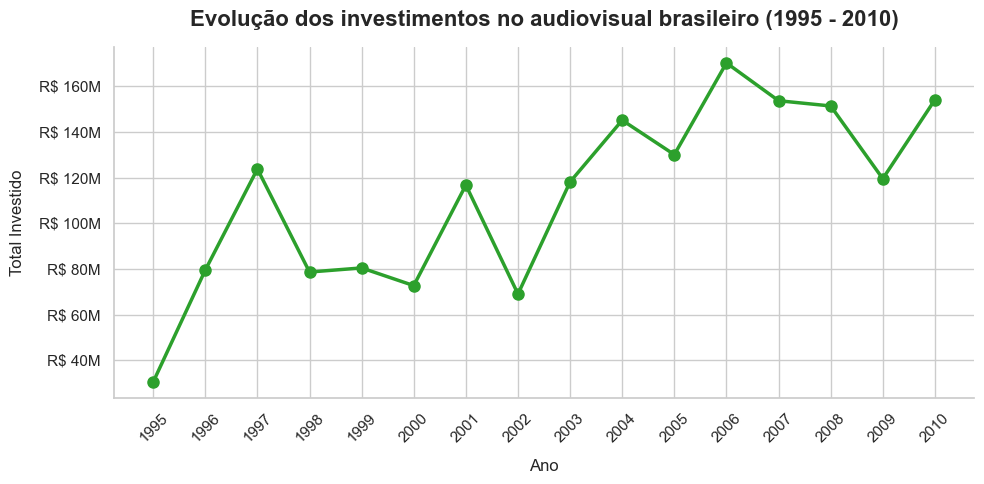

In [173]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Define um estilo mais moderno e limpo
sns.set_theme(style="whitegrid")

# 2. Cria a figura com um tamanho legal (largura x altura)
fig, ax = plt.subplots(figsize=(10, 5))

# 3. Plota os dados (usando o índice para o eixo X)
ax.plot(df_investimentos.index, df_investimentos['Investimento'], 
        marker='o',           # Bolinhas em cada ano
        linestyle='-',        # Linha contínua
        color='#2ca02c',      # Cor verde estilosa (mude se quiser!)
        linewidth=2.5,        # Espessura da linha
        markersize=8)         # Tamanho das bolinhas

# 4. Textos e Títulos
ax.set_title('Evolução dos investimentos no audiovisual brasileiro (1995 - 2010)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Ano', fontsize=12, labelpad=10)
ax.set_ylabel('Total Investido', fontsize=12, labelpad=10)

# 5. Formata o eixo Y para mostrar valores em Milhões (ex: 30M, 150M)
formatador = ticker.FuncFormatter(lambda x, pos: f'R$ {x*1e-6:.0f}M')
ax.yaxis.set_major_formatter(formatador)

# 6. Garante que todos os anos apareçam no eixo X
plt.xticks(df_investimentos.index, rotation=45)

# Remove as bordas superior e direita para um visual mais "clean"
sns.despine()

# Ajusta o layout para nada ficar cortado
plt.tight_layout()

# Exibe a obra de arte
plt.show()